In [1]:
import numpy as np
import random

In [2]:
import numpy as np
import random

class K_means:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):
        random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_index]

        for _ in range(self.max_iter):
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids.copy()

            self.centroids = self.move_centroids(X, cluster_group)

            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self, X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))

            index_pos = distances.index(min(distances))
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []
        cluster_types = np.unique(cluster_group)

        for t in cluster_types:
            new_centroids.append(X[cluster_group == t].mean(axis=0))

        return np.array(new_centroids)


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students/student_clustering.csv


In [4]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/kaggle/input/students/student_clustering.csv")
df.sample(6)

,cgpa,iq
30,8.86,117
94,8.67,95
191,8.44,94
67,4.91,85
132,5.01,83
65,8.75,113


In [5]:
X=df.iloc[:,:].values

In [6]:
km = K_means(n_clusters = 4 , max_iter = 500)
y_means = km.fit_predict(X)

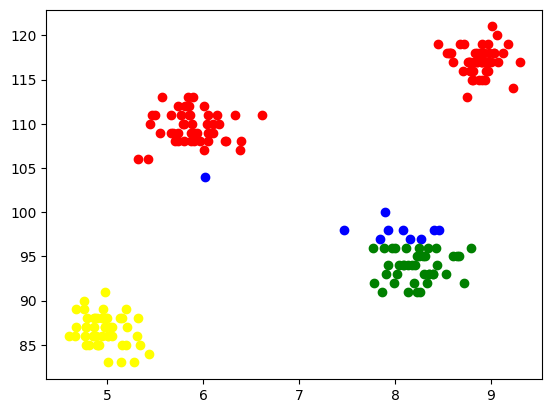

In [7]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')
plt.show()